# Load Data

In [7]:
import numpy as np

loaded = np.load("ecg_dataset.npz")
X = loaded["x"]
y = loaded["y"]

## Split Data

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [92]:
print("X_test shape:", X_test.shape)
print("Y_test shape:", y_test.shape)
print("Label counts:", np.unique(y_test, return_counts=True))

X_test shape: (3022, 5000, 12)
Y_test shape: (3022,)
Label counts: (array([0, 1]), array([1817, 1205], dtype=int64))


In [3]:
!pip install imblearn


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


### Under-Sampling

In [4]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_train.reshape((X_train.shape[0], -1)), y_train)
X_rus = X_rus.reshape((-1, 5000, 12))

print("After Under-Sampling:", np.bincount(y_rus))

C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


After Under-Sampling: [4819 4819]


### Over-Sampling

In [5]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X_train.reshape((X_train.shape[0], -1)), y_train)
X_ros = X_ros.reshape((-1, 5000, 12))  # Reshape back to original

print("After Over-Sampling:", np.bincount(y_ros))

C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


After Over-Sampling: [7266 7266]


# Model Creation

## Resiual Block

In [6]:
from tensorflow.keras import layers, Model, Input, models

def residual_block(x, filters, kernel_size=3, dropout_rate=0.3):
    shortcut = x

    x = layers.Conv1D(filters, kernel_size, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Conv1D(filters, kernel_size, padding='same')(x)
    x = layers.BatchNormalization()(x)


    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    x = layers.Dropout(dropout_rate)(x)

    return x

## Classifier

In [7]:
def build_classifier_from_features(n_features):
    inputs = Input(shape=(n_features,))
    outputs = layers.Dense(1, activation='sigmoid')(inputs)
    model = Model(inputs, outputs, name="ClassificationHead")
    return model

## Common Configurations

In [8]:
!pip install tensorflow-addons


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
from tensorflow.keras.metrics import Precision, Recall, AUC
from tensorflow_addons.metrics import F1Score
f1 = F1Score(num_classes=1, average='micro', threshold=0.5, name='f1')

compile_config = {
    'optimizer': 'adam',
    'loss': 'binary_crossentropy',
    'metrics': ['accuracy', Precision(name='precision'), Recall(name='recall'), AUC(name='auc'), f1]
}

C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\tensorflow_addons\utils\tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\tensorflow_addons\utils\ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.12.0 and strictly below 2.15.0 (nightly versions are not supported). 
 The versions of Tensor

## n - 32 Model

In [10]:
def build_residual_cnn_feature_extractor_32(input_shape):
    inputs = Input(shape=input_shape)

    x = layers.Conv1D(32, kernel_size=5, padding='same')(inputs)  # smaller filters
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = residual_block(x, filters=32, kernel_size=5, dropout_rate=0.2)
    x = residual_block(x, filters=32, kernel_size=5, dropout_rate=0.2)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.3)(x)
    features = layers.Dense(32, activation='relu')(x)  # Output: 32 features

    model = Model(inputs, features, name="ResidualCNN_FeatureExtractor_32")
    return model

In [11]:
feature_model_32 = build_residual_cnn_feature_extractor_32((5000, 12))
classifier_32 = build_classifier_from_features(32)
full_model_32 = models.Sequential([feature_model_32, classifier_32])

full_model_32.compile(**compile_config)

### Clone Model

In [12]:
from tensorflow.keras.models import clone_model

full_model_32_weight = clone_model(full_model_32)
full_model_32_weight.set_weights(full_model_32.get_weights())
full_model_32_weight.compile(**compile_config)

# Clone for oversampling
full_model_32_ros = clone_model(full_model_32)
full_model_32_ros.set_weights(full_model_32.get_weights())
full_model_32_ros.compile(**compile_config)

# Clone for undersampling
full_model_32_rus = clone_model(full_model_32)
full_model_32_rus.set_weights(full_model_32.get_weights())
full_model_32_rus.compile(**compile_config)

## n - 64 Model

In [13]:
def build_residual_cnn_feature_extractor_64(input_shape):
    inputs = Input(shape=input_shape)

    x = layers.Conv1D(48, kernel_size=3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = residual_block(x, filters=48, kernel_size=3, dropout_rate=0.25)
    x = residual_block(x, filters=48, kernel_size=3, dropout_rate=0.25)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.4)(x)
    features = layers.Dense(64, activation='relu')(x)  # Output: 64 features

    model = Model(inputs, features, name="ResidualCNN_FeatureExtractor_64")
    return model

In [14]:
feature_model_64 = build_residual_cnn_feature_extractor_64((5000, 12))
classifier_64 = build_classifier_from_features(64)
full_model_64 = models.Sequential([feature_model_64, classifier_64])

full_model_64.compile(**compile_config)

### Clone Model

In [72]:
from tensorflow.keras.models import clone_model

full_model_64_weight = clone_model(full_model_64)
full_model_64_weight.set_weights(full_model_64.get_weights())
full_model_64_weight.compile(**compile_config)

# Clone for oversampling
full_model_64_ros = clone_model(full_model_64)
full_model_64_ros.set_weights(full_model_64.get_weights())
full_model_64_ros.compile(**compile_config)

# Clone for undersampling
full_model_64_rus = clone_model(full_model_64)
full_model_64_rus.set_weights(full_model_64.get_weights())
full_model_64_rus.compile(**compile_config)

## n - 128 Model

In [16]:
def build_residual_cnn_feature_extractor_128(input_shape):
    inputs = Input(shape=input_shape)

    x = layers.Conv1D(64, kernel_size=3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = residual_block(x, filters=64, kernel_size=3, dropout_rate=0.3)

    x = residual_block(x, filters=64, kernel_size=3, dropout_rate=0.3)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.5)(x)
    features = layers.Dense(128, activation='relu')(x)

    feature_model = Model(inputs=inputs, outputs=features, name="ResidualCNN_FeatureExtractor_128")
    return feature_model


In [17]:
feature_model_128 = build_residual_cnn_feature_extractor_128((5000, 12))
classifier_128 = build_classifier_from_features(128)
full_model_128 = models.Sequential([feature_model_128, classifier_128])

full_model_128.compile(**compile_config)

### Clone Model

In [18]:
from tensorflow.keras.models import clone_model

full_model_128_weight = clone_model(full_model_128)
full_model_128_weight.set_weights(full_model_128.get_weights())
full_model_128_weight.compile(**compile_config)

# Clone for oversampling
full_model_128_ros = clone_model(full_model_128)
full_model_128_ros.set_weights(full_model_128.get_weights())
full_model_128_ros.compile(**compile_config)

# Clone for undersampling
full_model_128_rus = clone_model(full_model_128)
full_model_128_rus.set_weights(full_model_128.get_weights())
full_model_128_rus.compile(**compile_config)

## n -256 Model

In [19]:
def build_residual_cnn_feature_extractor_256(input_shape):
    inputs = Input(shape=input_shape)

    x = layers.Conv1D(128, kernel_size=3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = residual_block(x, filters=128, kernel_size=3, dropout_rate=0.3)

    x = residual_block(x, filters=128, kernel_size=3, dropout_rate=0.3)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.5)(x)
    features = layers.Dense(256, activation='relu')(x)

    feature_model = Model(inputs=inputs, outputs=features, name="ResidualCNN_FeatureExtractor_256")
    return feature_model

In [20]:
feature_model_256 = build_residual_cnn_feature_extractor_256((5000, 12))
classifier_256 = build_classifier_from_features(256)
full_model_256 = models.Sequential([feature_model_256, classifier_256])

full_model_256.compile(**compile_config)

### Clone Model

In [21]:
from tensorflow.keras.models import clone_model

full_model_256_weight = clone_model(full_model_256)
full_model_256_weight.set_weights(full_model_256.get_weights())
full_model_256_weight.compile(**compile_config)

# Clone for oversampling
full_model_256_ros = clone_model(full_model_256)
full_model_256_ros.set_weights(full_model_256.get_weights())
full_model_256_ros.compile(**compile_config)

# Clone for undersampling
full_model_256_rus = clone_model(full_model_256)
full_model_256_rus.set_weights(full_model_256.get_weights())
full_model_256_rus.compile(**compile_config)

# Train Model

## Callbacks

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
        monitor='val_f1',       # 
        patience=3,               # Stop after 3 epochs with no improvement
        restore_best_weights=True,
        mode="max"
    )

def get_checkpoint(model_name):
    checkpoint = ModelCheckpoint(
        model_name,                      # filename to save
        monitor="val_f1",          # what to track
        mode="max",                      # because higher val_accuracy is better
        save_best_only=True,             # only save if it's the best so far
        verbose=1                        # prints info when it saves
    )
    return checkpoint
    

## Base Model

### n - 32 Model

In [23]:
full_model_32.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stop, get_checkpoint("ResidualCNN_FeatureExtractor_32.h5")])

Epoch 1/100


378/378 [==============================] - ETA: 0s - loss: 0.4464 - accuracy: 0.8026 - precision: 0.7942 - recall: 0.6817 - auc: 0.8618 - f1: 0.7337
Epoch 1: val_f1 improved from -inf to 0.81047, saving model to ResidualCNN_FeatureExtractor_32.h5
378/378 [==============================] - 286s 741ms/step - loss: 0.4464 - accuracy: 0.8026 - precision: 0.7942 - recall: 0.6817 - auc: 0.8618 - f1: 0.7337 - val_loss: 0.3619 - val_accuracy: 0.8491 - val_precision: 0.8118 - val_recall: 0.8091 - val_auc: 0.9213 - val_f1: 0.8105
Epoch 2/100


C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


378/378 [==============================] - ETA: 0s - loss: 0.3932 - accuracy: 0.8296 - precision: 0.8241 - recall: 0.7282 - auc: 0.8929 - f1: 0.7732
Epoch 2: val_f1 improved from 0.81047 to 0.81163, saving model to ResidualCNN_FeatureExtractor_32.h5
378/378 [==============================] - 265s 701ms/step - loss: 0.3932 - accuracy: 0.8296 - precision: 0.8241 - recall: 0.7282 - auc: 0.8929 - f1: 0.7732 - val_loss: 0.3373 - val_accuracy: 0.8564 - val_precision: 0.8508 - val_recall: 0.7759 - val_auc: 0.9272 - val_f1: 0.8116
Epoch 3/100
378/378 [==============================] - ETA: 0s - loss: 0.3725 - accuracy: 0.8386 - precision: 0.8389 - recall: 0.7369 - auc: 0.9037 - f1: 0.7846
Epoch 3: val_f1 improved from 0.81163 to 0.82646, saving model to ResidualCNN_FeatureExtractor_32.h5
378/378 [==============================] - 261s 691ms/step - loss: 0.3725 - accuracy: 0.8386 - precision: 0.8389 - recall: 0.7369 - auc: 0.9037 - f1: 0.7846 - val_loss: 0.3319 - val_accuracy: 0.8663 - val_prec

### n - 64 Model

In [24]:
full_model_64.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stop, get_checkpoint("ResidualCNN_FeatureExtractor_64.h5")])

Epoch 1/100
378/378 [==============================] - ETA: 0s - loss: 0.4632 - accuracy: 0.7916 - precision: 0.8112 - recall: 0.6662 - auc: 0.8690 - f1: 0.7316
Epoch 1: val_f1 improved from -inf to 0.80554, saving model to ResidualCNN_FeatureExtractor_64.h5
378/378 [==============================] - 436s 1s/step - loss: 0.4632 - accuracy: 0.7916 - precision: 0.8112 - recall: 0.6662 - auc: 0.8690 - f1: 0.7316 - val_loss: 0.3734 - val_accuracy: 0.8468 - val_precision: 0.8155 - val_recall: 0.7959 - val_auc: 0.9132 - val_f1: 0.8055
Epoch 2/100
378/378 [==============================] - ETA: 0s - loss: 0.3981 - accuracy: 0.8283 - precision: 0.8300 - recall: 0.7161 - auc: 0.8891 - f1: 0.7689
Epoch 2: val_f1 did not improve from 0.80554
378/378 [==============================] - 399s 1s/step - loss: 0.3981 - accuracy: 0.8283 - precision: 0.8300 - recall: 0.7161 - auc: 0.8891 - f1: 0.7689 - val_loss: 0.3636 - val_accuracy: 0.8412 - val_precision: 0.9143 - val_recall: 0.6639 - val_auc: 0.9193 

### n - 128 Model

In [25]:
full_model_128.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stop, get_checkpoint("ResidualCNN_FeatureExtractor_128.h5")])

Epoch 1/100
378/378 [==============================] - ETA: 0s - loss: 0.4608 - accuracy: 0.7910 - precision: 0.8008 - recall: 0.6693 - auc: 0.8660 - f1: 0.7292
Epoch 1: val_f1 improved from -inf to 0.80134, saving model to ResidualCNN_FeatureExtractor_128.h5
378/378 [==============================] - 656s 2s/step - loss: 0.4608 - accuracy: 0.7910 - precision: 0.8008 - recall: 0.6693 - auc: 0.8660 - f1: 0.7292 - val_loss: 0.3648 - val_accuracy: 0.8432 - val_precision: 0.8095 - val_recall: 0.7934 - val_auc: 0.9124 - val_f1: 0.8013
Epoch 2/100
378/378 [==============================] - ETA: 0s - loss: 0.4062 - accuracy: 0.8232 - precision: 0.8217 - recall: 0.7107 - auc: 0.8853 - f1: 0.7622
Epoch 2: val_f1 did not improve from 0.80134
378/378 [==============================] - 617s 2s/step - loss: 0.4062 - accuracy: 0.8232 - precision: 0.8217 - recall: 0.7107 - auc: 0.8853 - f1: 0.7622 - val_loss: 0.3877 - val_accuracy: 0.8339 - val_precision: 0.9102 - val_recall: 0.6473 - val_auc: 0.9098

### n -256 Model

In [26]:
full_model_256.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stop, get_checkpoint("ResidualCNN_FeatureExtractor_256.h5")])

Epoch 1/100
378/378 [==============================] - ETA: 0s - loss: 0.4452 - accuracy: 0.8039 - precision: 0.8164 - recall: 0.6931 - auc: 0.8792 - f1: 0.7497
Epoch 1: val_f1 improved from -inf to 0.79376, saving model to ResidualCNN_FeatureExtractor_256.h5
378/378 [==============================] - 2026s 5s/step - loss: 0.4452 - accuracy: 0.8039 - precision: 0.8164 - recall: 0.6931 - auc: 0.8792 - f1: 0.7497 - val_loss: 0.3494 - val_accuracy: 0.8468 - val_precision: 0.8567 - val_recall: 0.7394 - val_auc: 0.9171 - val_f1: 0.7938
Epoch 2/100
378/378 [==============================] - ETA: 0s - loss: 0.3917 - accuracy: 0.8280 - precision: 0.8289 - recall: 0.7165 - auc: 0.8922 - f1: 0.7686
Epoch 2: val_f1 improved from 0.79376 to 0.80637, saving model to ResidualCNN_FeatureExtractor_256.h5
378/378 [==============================] - 1979s 5s/step - loss: 0.3917 - accuracy: 0.8280 - precision: 0.8289 - recall: 0.7165 - auc: 0.8922 - f1: 0.7686 - val_loss: 0.3672 - val_accuracy: 0.8392 - v

## Class Weights

In [27]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = {i: w for i, w in enumerate(class_weights)}
print("Class Weights:", class_weights_dict)

Class Weights: {0: 0.8316129920176163, 1: 1.2538908487238016}


### n - 32 Model

In [28]:
full_model_32_weight.fit(X_train, y_train, epochs=100, batch_size=32, class_weight=class_weights_dict, validation_data=(X_test, y_test), callbacks=[early_stop, get_checkpoint("Weighted_ResidualCNN_FeatureExtractor_32.h5")])

Epoch 1/100
378/378 [==============================] - ETA: 0s - loss: 0.4750 - accuracy: 0.7881 - precision: 0.7534 - recall: 0.7555 - auc: 0.8733 - f1: 0.7544
Epoch 1: val_f1 improved from -inf to 0.75714, saving model to Weighted_ResidualCNN_FeatureExtractor_32.h5
378/378 [==============================] - 297s 772ms/step - loss: 0.4750 - accuracy: 0.7881 - precision: 0.7534 - recall: 0.7555 - auc: 0.8733 - f1: 0.7544 - val_loss: 0.3811 - val_accuracy: 0.8283 - val_precision: 0.8680 - val_recall: 0.6714 - val_auc: 0.9054 - val_f1: 0.7571
Epoch 2/100


C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


378/378 [==============================] - ETA: 0s - loss: 0.4066 - accuracy: 0.8228 - precision: 0.7727 - recall: 0.7871 - auc: 0.8942 - f1: 0.7798
Epoch 2: val_f1 improved from 0.75714 to 0.81167, saving model to Weighted_ResidualCNN_FeatureExtractor_32.h5
378/378 [==============================] - 273s 722ms/step - loss: 0.4066 - accuracy: 0.8228 - precision: 0.7727 - recall: 0.7871 - auc: 0.8942 - f1: 0.7798 - val_loss: 0.3457 - val_accuracy: 0.8504 - val_precision: 0.8151 - val_recall: 0.8083 - val_auc: 0.9247 - val_f1: 0.8117
Epoch 3/100
378/378 [==============================] - ETA: 0s - loss: 0.3874 - accuracy: 0.8345 - precision: 0.7914 - recall: 0.7944 - auc: 0.9037 - f1: 0.7929
Epoch 3: val_f1 improved from 0.81167 to 0.81767, saving model to Weighted_ResidualCNN_FeatureExtractor_32.h5
378/378 [==============================] - 274s 724ms/step - loss: 0.3874 - accuracy: 0.8345 - precision: 0.7914 - recall: 0.7944 - auc: 0.9037 - f1: 0.7929 - val_loss: 0.3384 - val_accuracy:

### n - 64 Model

In [29]:
full_model_64_weight.fit(X_train, y_train, epochs=100, batch_size=32, class_weight=class_weights_dict, validation_data=(X_test, y_test), callbacks=[early_stop, get_checkpoint("Weighted_ResidualCNN_FeatureExtractor_64.h5")])

Epoch 1/100
378/378 [==============================] - ETA: 0s - loss: 0.4760 - accuracy: 0.7794 - precision: 0.7428 - recall: 0.7570 - auc: 0.8739 - f1: 0.7498
Epoch 1: val_f1 improved from -inf to 0.80197, saving model to Weighted_ResidualCNN_FeatureExtractor_64.h5
378/378 [==============================] - 443s 1s/step - loss: 0.4760 - accuracy: 0.7794 - precision: 0.7428 - recall: 0.7570 - auc: 0.8739 - f1: 0.7498 - val_loss: 0.3716 - val_accuracy: 0.8402 - val_precision: 0.7925 - val_recall: 0.8116 - val_auc: 0.9168 - val_f1: 0.8020
Epoch 2/100
378/378 [==============================] - ETA: 0s - loss: 0.4160 - accuracy: 0.8180 - precision: 0.7700 - recall: 0.7753 - auc: 0.8882 - f1: 0.7726
Epoch 2: val_f1 improved from 0.80197 to 0.81733, saving model to Weighted_ResidualCNN_FeatureExtractor_64.h5
378/378 [==============================] - 437s 1s/step - loss: 0.4160 - accuracy: 0.8180 - precision: 0.7700 - recall: 0.7753 - auc: 0.8882 - f1: 0.7726 - val_loss: 0.3478 - val_accura

### n - 128 Model

In [30]:
full_model_128_weight.fit(X_train, y_train, epochs=100, batch_size=32, class_weight=class_weights_dict, validation_data=(X_test, y_test), callbacks=[early_stop, get_checkpoint("Weighted_ResidualCNN_FeatureExtractor_128.h5")])

Epoch 1/100
378/378 [==============================] - ETA: 0s - loss: 0.4826 - accuracy: 0.7816 - precision: 0.7229 - recall: 0.7792 - auc: 0.8639 - f1: 0.7500
Epoch 1: val_f1 improved from -inf to 0.77594, saving model to Weighted_ResidualCNN_FeatureExtractor_128.h5
378/378 [==============================] - 577s 2s/step - loss: 0.4826 - accuracy: 0.7816 - precision: 0.7229 - recall: 0.7792 - auc: 0.8639 - f1: 0.7500 - val_loss: 0.3757 - val_accuracy: 0.8385 - val_precision: 0.8684 - val_recall: 0.7012 - val_auc: 0.9043 - val_f1: 0.7759
Epoch 2/100
378/378 [==============================] - ETA: 0s - loss: 0.4185 - accuracy: 0.8166 - precision: 0.7671 - recall: 0.7757 - auc: 0.8882 - f1: 0.7714
Epoch 2: val_f1 improved from 0.77594 to 0.80318, saving model to Weighted_ResidualCNN_FeatureExtractor_128.h5
378/378 [==============================] - 564s 1s/step - loss: 0.4185 - accuracy: 0.8166 - precision: 0.7671 - recall: 0.7757 - auc: 0.8882 - f1: 0.7714 - val_loss: 0.3491 - val_accu

### n - 256 Model

In [31]:
full_model_256_weight.fit(X_train, y_train, epochs=100, batch_size=32, class_weight=class_weights_dict, validation_data=(X_test, y_test), callbacks=[early_stop, get_checkpoint("Weighted_ResidualCNN_FeatureExtractor_256.h5")])

Epoch 1/100
378/378 [==============================] - ETA: 0s - loss: 0.4718 - accuracy: 0.7877 - precision: 0.7452 - recall: 0.7722 - auc: 0.8760 - f1: 0.7585
Epoch 1: val_f1 improved from -inf to 0.80139, saving model to Weighted_ResidualCNN_FeatureExtractor_256.h5
378/378 [==============================] - 2110s 6s/step - loss: 0.4718 - accuracy: 0.7877 - precision: 0.7452 - recall: 0.7722 - auc: 0.8760 - f1: 0.7585 - val_loss: 0.3543 - val_accuracy: 0.8484 - val_precision: 0.8392 - val_recall: 0.7668 - val_auc: 0.9171 - val_f1: 0.8014
Epoch 2/100
378/378 [==============================] - ETA: 0s - loss: 0.4102 - accuracy: 0.8199 - precision: 0.7706 - recall: 0.7809 - auc: 0.8919 - f1: 0.7757
Epoch 2: val_f1 did not improve from 0.80139
378/378 [==============================] - 2043s 5s/step - loss: 0.4102 - accuracy: 0.8199 - precision: 0.7706 - recall: 0.7809 - auc: 0.8919 - f1: 0.7757 - val_loss: 0.3627 - val_accuracy: 0.8369 - val_precision: 0.8708 - val_recall: 0.6938 - val_

## Under-Sampling

### n - 32 Model

In [32]:
full_model_32_rus.fit(X_rus, y_rus, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stop, get_checkpoint("Under_Sampled_ResidualCNN_FeatureExtractor_32.h5")])

Epoch 1/100
302/302 [==============================] - ETA: 0s - loss: 0.4721 - accuracy: 0.7817 - precision: 0.8244 - recall: 0.7367 - auc: 0.8775 - f1: 0.7781
Epoch 1: val_f1 improved from -inf to 0.77909, saving model to Under_Sampled_ResidualCNN_FeatureExtractor_32.h5
302/302 [==============================] - 196s 634ms/step - loss: 0.4721 - accuracy: 0.7817 - precision: 0.8244 - recall: 0.7367 - auc: 0.8775 - f1: 0.7781 - val_loss: 0.3670 - val_accuracy: 0.8392 - val_precision: 0.8613 - val_recall: 0.7112 - val_auc: 0.9096 - val_f1: 0.7791
Epoch 2/100
302/302 [==============================] - ETA: 0s - loss: 0.4286 - accuracy: 0.8039 - precision: 0.8262 - recall: 0.7697 - auc: 0.8813 - f1: 0.7969
Epoch 2: val_f1 improved from 0.77909 to 0.78899, saving model to Under_Sampled_ResidualCNN_FeatureExtractor_32.h5
302/302 [==============================] - 195s 646ms/step - loss: 0.4286 - accuracy: 0.8039 - precision: 0.8262 - recall: 0.7697 - auc: 0.8813 - f1: 0.7969 - val_loss: 0.3

### n - 64 Model

In [33]:
full_model_64_rus.fit(X_rus, y_rus, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stop, get_checkpoint("Under_Sampled_ResidualCNN_FeatureExtractor_64.h5")])

Epoch 1/100
302/302 [==============================] - ETA: 0s - loss: 0.4908 - accuracy: 0.7687 - precision: 0.7357 - recall: 0.7800 - auc: 0.8429 - f1: 0.7572
Epoch 1: val_f1 improved from -inf to 0.73664, saving model to Under_Sampled_ResidualCNN_FeatureExtractor_64.h5
302/302 [==============================] - 299s 977ms/step - loss: 0.4908 - accuracy: 0.7687 - precision: 0.7357 - recall: 0.7800 - auc: 0.8429 - f1: 0.7572 - val_loss: 0.3980 - val_accuracy: 0.8223 - val_precision: 0.9005 - val_recall: 0.6232 - val_auc: 0.9064 - val_f1: 0.7366
Epoch 2/100
302/302 [==============================] - ETA: 0s - loss: 0.4281 - accuracy: 0.8064 - precision: 0.8279 - recall: 0.7736 - auc: 0.8820 - f1: 0.7998
Epoch 2: val_f1 improved from 0.73664 to 0.80825, saving model to Under_Sampled_ResidualCNN_FeatureExtractor_64.h5
302/302 [==============================] - 291s 963ms/step - loss: 0.4281 - accuracy: 0.8064 - precision: 0.8279 - recall: 0.7736 - auc: 0.8820 - f1: 0.7998 - val_loss: 0.3

### n - 128 Model

In [34]:
full_model_128_rus.fit(X_rus, y_rus, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stop, get_checkpoint("Under_Sampled_ResidualCNN_FeatureExtractor_128.h5")])

Epoch 1/100
302/302 [==============================] - ETA: 0s - loss: 0.4948 - accuracy: 0.7695 - precision: 0.7712 - recall: 0.7779 - auc: 0.8612 - f1: 0.7745
Epoch 1: val_f1 improved from -inf to 0.79887, saving model to Under_Sampled_ResidualCNN_FeatureExtractor_128.h5
302/302 [==============================] - 503s 2s/step - loss: 0.4948 - accuracy: 0.7695 - precision: 0.7712 - recall: 0.7779 - auc: 0.8612 - f1: 0.7745 - val_loss: 0.3792 - val_accuracy: 0.8352 - val_precision: 0.7781 - val_recall: 0.8207 - val_auc: 0.9107 - val_f1: 0.7989
Epoch 2/100
302/302 [==============================] - ETA: 0s - loss: 0.4350 - accuracy: 0.7995 - precision: 0.8214 - recall: 0.7655 - auc: 0.8778 - f1: 0.7925
Epoch 2: val_f1 did not improve from 0.79887
302/302 [==============================] - 503s 2s/step - loss: 0.4350 - accuracy: 0.7995 - precision: 0.8214 - recall: 0.7655 - auc: 0.8778 - f1: 0.7925 - val_loss: 0.3683 - val_accuracy: 0.8475 - val_precision: 0.8654 - val_recall: 0.7311 - v

### n - 256 Model

In [87]:
full_model_256_rus.fit(X_rus, y_rus, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stop, get_checkpoint("Under_Sampled_ResidualCNN_FeatureExtractor_256.h5")])

Epoch 1/100
302/302 [==============================] - ETA: 0s - loss: 0.4898 - accuracy: 0.7732 - precision: 0.8109 - recall: 0.7434 - auc: 0.8719 - f1: 0.7757
Epoch 1: val_f1 improved from -inf to 0.77798, saving model to Under_Sampled_ResidualCNN_FeatureExtractor_256.h5
302/302 [==============================] - 1503s 5s/step - loss: 0.4898 - accuracy: 0.7732 - precision: 0.8109 - recall: 0.7434 - auc: 0.8719 - f1: 0.7757 - val_loss: 0.4452 - val_accuracy: 0.7958 - val_precision: 0.6868 - val_recall: 0.8971 - val_auc: 0.9089 - val_f1: 0.7780
Epoch 2/100


C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


302/302 [==============================] - ETA: 0s - loss: 0.4203 - accuracy: 0.8105 - precision: 0.8335 - recall: 0.7761 - auc: 0.8878 - f1: 0.8038
Epoch 2: val_f1 improved from 0.77798 to 0.81245, saving model to Under_Sampled_ResidualCNN_FeatureExtractor_256.h5
302/302 [==============================] - 1487s 5s/step - loss: 0.4203 - accuracy: 0.8105 - precision: 0.8335 - recall: 0.7761 - auc: 0.8878 - f1: 0.8038 - val_loss: 0.3564 - val_accuracy: 0.8504 - val_precision: 0.8124 - val_recall: 0.8124 - val_auc: 0.9216 - val_f1: 0.8124
Epoch 3/100
302/302 [==============================] - ETA: 0s - loss: 0.3893 - accuracy: 0.8252 - precision: 0.8490 - recall: 0.7910 - auc: 0.9026 - f1: 0.8190
Epoch 3: val_f1 did not improve from 0.81245
302/302 [==============================] - 1483s 5s/step - loss: 0.3893 - accuracy: 0.8252 - precision: 0.8490 - recall: 0.7910 - auc: 0.9026 - f1: 0.8190 - val_loss: 0.4220 - val_accuracy: 0.8240 - val_precision: 0.7254 - val_recall: 0.8988 - val_auc:

## Over-Sampling

### n - 32 Model

In [68]:
full_model_32_ros.fit(X_ros, y_ros, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stop, get_checkpoint("Over_Sampled_ResidualCNN_FeatureExtractor_32.h5")])

Epoch 1/100


455/455 [==============================] - ETA: 0s - loss: 0.4620 - accuracy: 0.7850 - precision: 0.8044 - recall: 0.7530 - auc: 0.8615 - f1: 0.7778
Epoch 1: val_f1 improved from -inf to 0.78835, saving model to Over_Sampled_ResidualCNN_FeatureExtractor_32.h5
455/455 [==============================] - 370s 799ms/step - loss: 0.4620 - accuracy: 0.7850 - precision: 0.8044 - recall: 0.7530 - auc: 0.8615 - f1: 0.7778 - val_loss: 0.4240 - val_accuracy: 0.8124 - val_precision: 0.7164 - val_recall: 0.8763 - val_auc: 0.9161 - val_f1: 0.7884
Epoch 2/100


C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


455/455 [==============================] - ETA: 0s - loss: 0.4079 - accuracy: 0.8143 - precision: 0.8330 - recall: 0.7863 - auc: 0.8935 - f1: 0.8090
Epoch 2: val_f1 improved from 0.78835 to 0.79728, saving model to Over_Sampled_ResidualCNN_FeatureExtractor_32.h5
455/455 [==============================] - 344s 757ms/step - loss: 0.4079 - accuracy: 0.8143 - precision: 0.8330 - recall: 0.7863 - auc: 0.8935 - f1: 0.8090 - val_loss: 0.3463 - val_accuracy: 0.8521 - val_precision: 0.8790 - val_recall: 0.7295 - val_auc: 0.9248 - val_f1: 0.7973
Epoch 3/100
455/455 [==============================] - ETA: 0s - loss: 0.3875 - accuracy: 0.8297 - precision: 0.8486 - recall: 0.8025 - auc: 0.9038 - f1: 0.8249
Epoch 3: val_f1 improved from 0.79728 to 0.81574, saving model to Over_Sampled_ResidualCNN_FeatureExtractor_32.h5
455/455 [==============================] - 346s 761ms/step - loss: 0.3875 - accuracy: 0.8297 - precision: 0.8486 - recall: 0.8025 - auc: 0.9038 - f1: 0.8249 - val_loss: 0.3265 - val_a

### n - 64 Model

In [73]:
full_model_64_ros.fit(X_ros, y_ros, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stop, get_checkpoint("Over_Sampled_ResidualCNN_FeatureExtractor_64.h5")])

Epoch 1/100
455/455 [==============================] - ETA: 0s - loss: 0.4729 - accuracy: 0.7764 - precision: 0.8086 - recall: 0.7388 - auc: 0.8710 - f1: 0.7721
Epoch 1: val_f1 improved from -inf to 0.78129, saving model to Over_Sampled_ResidualCNN_FeatureExtractor_64.h5
455/455 [==============================] - 527s 1s/step - loss: 0.4729 - accuracy: 0.7764 - precision: 0.8086 - recall: 0.7388 - auc: 0.8710 - f1: 0.7721 - val_loss: 0.3616 - val_accuracy: 0.8422 - val_precision: 0.8730 - val_recall: 0.7071 - val_auc: 0.9127 - val_f1: 0.7813
Epoch 2/100
455/455 [==============================] - ETA: 0s - loss: 0.4151 - accuracy: 0.8130 - precision: 0.8379 - recall: 0.7762 - auc: 0.8892 - f1: 0.8059
Epoch 2: val_f1 improved from 0.78129 to 0.81629, saving model to Over_Sampled_ResidualCNN_FeatureExtractor_64.h5
455/455 [==============================] - 463s 1s/step - loss: 0.4151 - accuracy: 0.8130 - precision: 0.8379 - recall: 0.7762 - auc: 0.8892 - f1: 0.8059 - val_loss: 0.3583 - va

### n - 128 Model

In [74]:
full_model_128_ros.fit(X_ros, y_ros, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stop, get_checkpoint("Over_Sampled_ResidualCNN_FeatureExtractor_128.h5")])

Epoch 1/100
455/455 [==============================] - ETA: 0s - loss: 0.4841 - accuracy: 0.7721 - precision: 0.8069 - recall: 0.7304 - auc: 0.8643 - f1: 0.7667
Epoch 1: val_f1 improved from -inf to 0.74389, saving model to Over_Sampled_ResidualCNN_FeatureExtractor_128.h5
455/455 [==============================] - 680s 1s/step - loss: 0.4841 - accuracy: 0.7721 - precision: 0.8069 - recall: 0.7304 - auc: 0.8643 - f1: 0.7667 - val_loss: 0.3720 - val_accuracy: 0.8266 - val_precision: 0.9049 - val_recall: 0.6315 - val_auc: 0.9152 - val_f1: 0.7439
Epoch 2/100
455/455 [==============================] - ETA: 0s - loss: 0.4098 - accuracy: 0.8165 - precision: 0.8406 - recall: 0.7810 - auc: 0.8927 - f1: 0.8097
Epoch 2: val_f1 did not improve from 0.74389
455/455 [==============================] - 670s 1s/step - loss: 0.4098 - accuracy: 0.8165 - precision: 0.8406 - recall: 0.7810 - auc: 0.8927 - f1: 0.8097 - val_loss: 0.5707 - val_accuracy: 0.6774 - val_precision: 0.5553 - val_recall: 0.9577 - va

### n - 256 Model

In [88]:
full_model_256_ros.fit(X_ros, y_ros, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stop, get_checkpoint("Over_Sampled_ResidualCNN_FeatureExtractor_256.h5")])

Epoch 1/100
455/455 [==============================] - ETA: 0s - loss: 0.4640 - accuracy: 0.7845 - precision: 0.8166 - recall: 0.7500 - auc: 0.8770 - f1: 0.7819
Epoch 1: val_f1 improved from -inf to 0.76540, saving model to Over_Sampled_ResidualCNN_FeatureExtractor_256.h5
455/455 [==============================] - 2614s 6s/step - loss: 0.4640 - accuracy: 0.7845 - precision: 0.8166 - recall: 0.7500 - auc: 0.8770 - f1: 0.7819 - val_loss: 0.3622 - val_accuracy: 0.8349 - val_precision: 0.8829 - val_recall: 0.6755 - val_auc: 0.9163 - val_f1: 0.7654
Epoch 2/100
455/455 [==============================] - ETA: 0s - loss: 0.4000 - accuracy: 0.8173 - precision: 0.8425 - recall: 0.7805 - auc: 0.8962 - f1: 0.8103
Epoch 2: val_f1 improved from 0.76540 to 0.81592, saving model to Over_Sampled_ResidualCNN_FeatureExtractor_256.h5
455/455 [==============================] - 2535s 6s/step - loss: 0.4000 - accuracy: 0.8173 - precision: 0.8425 - recall: 0.7805 - auc: 0.8962 - f1: 0.8103 - val_loss: 0.3428 

# Confusion Matrix

## Imports

In [11]:
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.metrics import  roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

## Base Model

### n- 32 Model

In [ ]:
model_32 = load_model('models/ResidualCNN/ResidualCNN_FeatureExtractor_32.h5')

In [13]:
y_probs_32 = model_32.predict(X_test, verbose=0)
y_pred_32 = (y_probs_32 >= 0.5).astype(int).flatten() 

In [14]:
# Accuracy
acc = accuracy_score(y_test, y_pred_32)

# Precision, Recall, F1
precision = precision_score(y_test, y_pred_32)
recall = recall_score(y_test, y_pred_32)
f1 = f1_score(y_test, y_pred_32)

# AUC
auc = roc_auc_score(y_test, y_probs_32)

# Print all
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC:       {auc:.4f}")

Accuracy:  0.8723
Precision: 0.8882
Recall:    0.7776
F1 Score:  0.8292
AUC:       0.9386


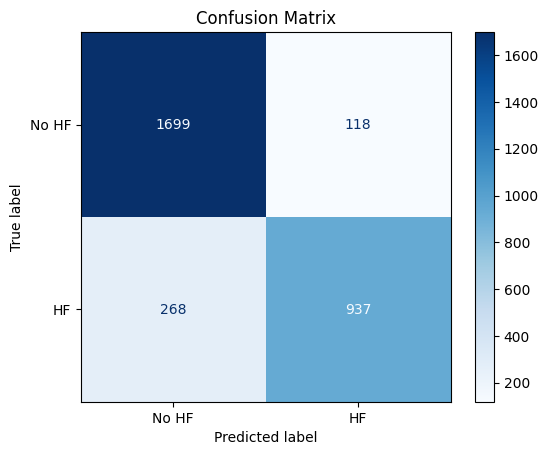

In [15]:
cm_32 = confusion_matrix(y_test, y_pred_32)
disp_32 = ConfusionMatrixDisplay(confusion_matrix=cm_32, display_labels=['No HF', 'HF'])
disp_32.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [16]:
print(classification_report(y_test, y_pred_32, target_names=["No HF", "HF"]))

              precision    recall  f1-score   support

       No HF       0.86      0.94      0.90      1817
          HF       0.89      0.78      0.83      1205

    accuracy                           0.87      3022
   macro avg       0.88      0.86      0.86      3022
weighted avg       0.87      0.87      0.87      3022



### n - 64 Model

In [ ]:
model_64 = load_model('models/ResidualCNN/ResidualCNN_FeatureExtractor_64.h5')

In [18]:
y_probs_64 = model_64.predict(X_test, verbose=0)
y_pred_64 = (y_probs_64 >= 0.5).astype(int).flatten() 

In [19]:
# Accuracy
acc = accuracy_score(y_test, y_pred_64)

# Precision, Recall, F1
precision = precision_score(y_test, y_pred_64)
recall = recall_score(y_test, y_pred_64)
f1 = f1_score(y_test, y_pred_64)

# AUC
auc = roc_auc_score(y_test, y_probs_64)

# Print all
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC:       {auc:.4f}")

Accuracy:  0.8633
Precision: 0.8128
Recall:    0.8539
F1 Score:  0.8329
AUC:       0.9332


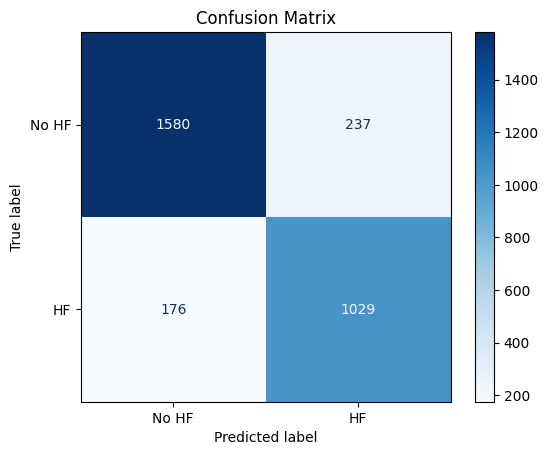

In [20]:
cm_64 = confusion_matrix(y_test, y_pred_64)
disp_64 = ConfusionMatrixDisplay(confusion_matrix=cm_64, display_labels=['No HF', 'HF'])
disp_64.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [21]:
print(classification_report(y_test, y_pred_64, target_names=["No HF", "HF"]))

              precision    recall  f1-score   support

       No HF       0.90      0.87      0.88      1817
          HF       0.81      0.85      0.83      1205

    accuracy                           0.86      3022
   macro avg       0.86      0.86      0.86      3022
weighted avg       0.87      0.86      0.86      3022



### n - 128 Model

In [ ]:
model_128 = load_model('models/ResidualCNN/ResidualCNN_FeatureExtractor_128.h5')

In [23]:
y_probs_128 = model_128.predict(X_test, verbose=0)
y_pred_128 = (y_probs_128 >= 0.5).astype(int).flatten() 

In [24]:
# Accuracy
acc = accuracy_score(y_test, y_pred_128)

# Precision, Recall, F1
precision = precision_score(y_test, y_pred_128)
recall = recall_score(y_test, y_pred_128)
f1 = f1_score(y_test, y_pred_128)

# AUC
auc = roc_auc_score(y_test, y_probs_128)

# Print all
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC:       {auc:.4f}")

Accuracy:  0.8620
Precision: 0.8093
Recall:    0.8556
F1 Score:  0.8318
AUC:       0.9321


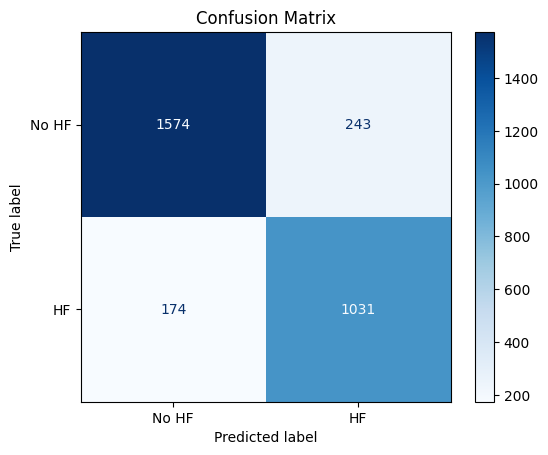

In [25]:
cm_128 = confusion_matrix(y_test, y_pred_128)
disp_128 = ConfusionMatrixDisplay(confusion_matrix=cm_128, display_labels=['No HF', 'HF'])
disp_128.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [26]:
print(classification_report(y_test, y_pred_128, target_names=["No HF", "HF"]))

              precision    recall  f1-score   support

       No HF       0.90      0.87      0.88      1817
          HF       0.81      0.86      0.83      1205

    accuracy                           0.86      3022
   macro avg       0.85      0.86      0.86      3022
weighted avg       0.86      0.86      0.86      3022



### n - 256 Model

In [ ]:
model_256 = load_model('models/ResidualCNN/ResidualCNN_FeatureExtractor_256.h5')

In [28]:
y_probs_256 = model_256.predict(X_test, verbose=0)
y_pred_256 = (y_probs_256 >= 0.5).astype(int).flatten() 

In [29]:
# Accuracy
acc = accuracy_score(y_test, y_pred_256)

# Precision, Recall, F1
precision = precision_score(y_test, y_pred_256)
recall = recall_score(y_test, y_pred_256)
f1 = f1_score(y_test, y_pred_256)

# AUC
auc = roc_auc_score(y_test, y_probs_256)

# Print all
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC:       {auc:.4f}")

Accuracy:  0.8673
Precision: 0.8328
Recall:    0.8349
F1 Score:  0.8338
AUC:       0.9365


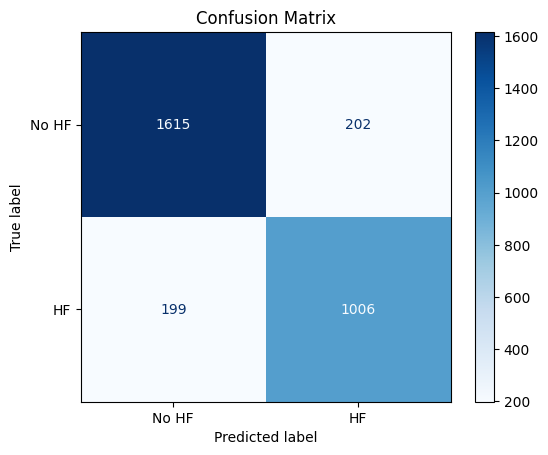

In [30]:
cm_256 = confusion_matrix(y_test, y_pred_256)
disp_256 = ConfusionMatrixDisplay(confusion_matrix=cm_256, display_labels=['No HF', 'HF'])
disp_256.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [31]:
print(classification_report(y_test, y_pred_256, target_names=["No HF", "HF"]))

              precision    recall  f1-score   support

       No HF       0.89      0.89      0.89      1817
          HF       0.83      0.83      0.83      1205

    accuracy                           0.87      3022
   macro avg       0.86      0.86      0.86      3022
weighted avg       0.87      0.87      0.87      3022



## Class Weights

### n - 32 Model

In [ ]:
model_32_weighted = load_model('models/ResidualCNN/Weighted_ResidualCNN_FeatureExtractor_32.h5')

In [33]:
y_probs_32_weighted = model_32_weighted.predict(X_test, verbose=0)
y_pred_32_weighted = (y_probs_32_weighted >= 0.5).astype(int).flatten() 

In [34]:
# Accuracy
acc = accuracy_score(y_test, y_pred_32_weighted)

# Precision, Recall, F1
precision = precision_score(y_test, y_pred_32_weighted)
recall = recall_score(y_test, y_pred_32_weighted)
f1 = f1_score(y_test, y_pred_32_weighted)

# AUC
auc = roc_auc_score(y_test, y_probs_32_weighted)

# Print all
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC:       {auc:.4f}")

Accuracy:  0.8762
Precision: 0.8629
Recall:    0.8199
F1 Score:  0.8409
AUC:       0.9404


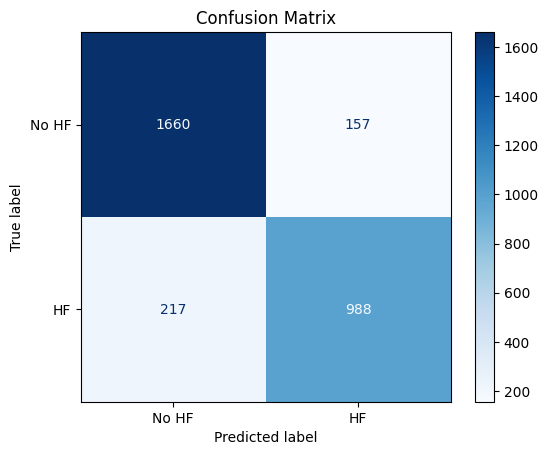

In [35]:
cm_32_weighted = confusion_matrix(y_test, y_pred_32_weighted)
disp_32_weighted = ConfusionMatrixDisplay(confusion_matrix=cm_32_weighted, display_labels=['No HF', 'HF'])
disp_32_weighted.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [36]:
print(classification_report(y_test, y_pred_32_weighted, target_names=["No HF", "HF"]))

              precision    recall  f1-score   support

       No HF       0.88      0.91      0.90      1817
          HF       0.86      0.82      0.84      1205

    accuracy                           0.88      3022
   macro avg       0.87      0.87      0.87      3022
weighted avg       0.88      0.88      0.88      3022



### n - 64 Model

In [ ]:
model_64_weighted = load_model('models/ResidualCNN/Weighted_ResidualCNN_FeatureExtractor_64.h5')

In [38]:
y_probs_64_weighted = model_64_weighted.predict(X_test, verbose=0)
y_pred_64_weighted = (y_probs_64_weighted >= 0.5).astype(int).flatten() 

In [39]:
# Accuracy
acc = accuracy_score(y_test, y_pred_64_weighted)

# Precision, Recall, F1
precision = precision_score(y_test, y_pred_64_weighted)
recall = recall_score(y_test, y_pred_64_weighted)
f1 = f1_score(y_test, y_pred_64_weighted)

# AUC
auc = roc_auc_score(y_test, y_probs_64_weighted)

# Print all
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC:       {auc:.4f}")

Accuracy:  0.8577
Precision: 0.8372
Recall:    0.7983
F1 Score:  0.8173
AUC:       0.9237


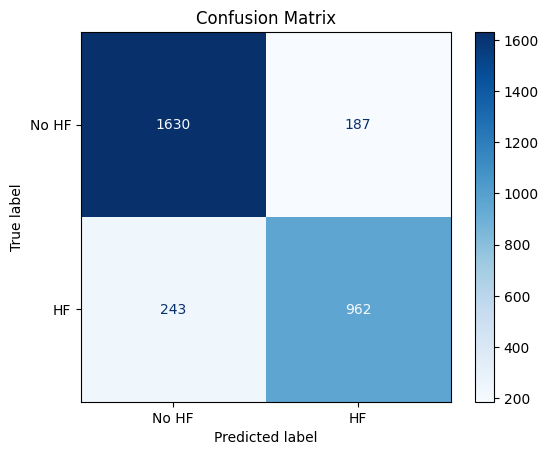

In [40]:
cm_64_weighted = confusion_matrix(y_test, y_pred_64_weighted)
disp_64_weighted = ConfusionMatrixDisplay(confusion_matrix=cm_64_weighted, display_labels=['No HF', 'HF'])
disp_64_weighted.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [41]:
print(classification_report(y_test, y_pred_64_weighted, target_names=["No HF", "HF"]))

              precision    recall  f1-score   support

       No HF       0.87      0.90      0.88      1817
          HF       0.84      0.80      0.82      1205

    accuracy                           0.86      3022
   macro avg       0.85      0.85      0.85      3022
weighted avg       0.86      0.86      0.86      3022



### n - 128 Model

In [ ]:
model_128_weighted = load_model('models/ResidualCNN/Weighted_ResidualCNN_FeatureExtractor_128.h5')

In [43]:
y_probs_128_weighted = model_128_weighted.predict(X_test, verbose=0)
y_pred_128_weighted = (y_probs_128_weighted >= 0.5).astype(int).flatten() 

In [44]:
# Accuracy
acc = accuracy_score(y_test, y_pred_128_weighted)

# Precision, Recall, F1
precision = precision_score(y_test, y_pred_128_weighted)
recall = recall_score(y_test, y_pred_128_weighted)
f1 = f1_score(y_test, y_pred_128_weighted)

# AUC
auc = roc_auc_score(y_test, y_probs_128_weighted)

# Print all
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC:       {auc:.4f}")

Accuracy:  0.8762
Precision: 0.8448
Recall:    0.8448
F1 Score:  0.8448
AUC:       0.9355


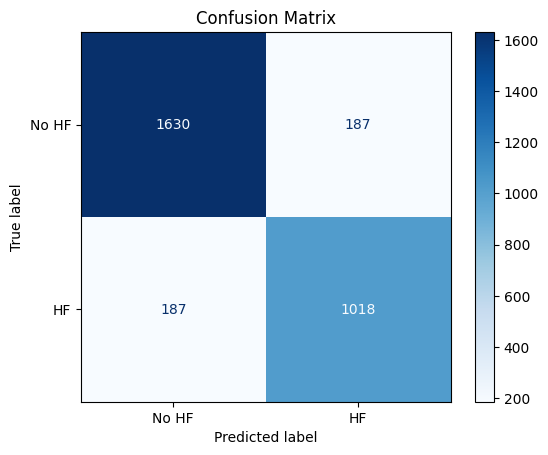

In [45]:
cm_128_weighted = confusion_matrix(y_test, y_pred_128_weighted)
disp_128_weighted = ConfusionMatrixDisplay(confusion_matrix=cm_128_weighted, display_labels=['No HF', 'HF'])
disp_128_weighted.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [46]:
print(classification_report(y_test, y_pred_128_weighted, target_names=["No HF", "HF"]))

              precision    recall  f1-score   support

       No HF       0.90      0.90      0.90      1817
          HF       0.84      0.84      0.84      1205

    accuracy                           0.88      3022
   macro avg       0.87      0.87      0.87      3022
weighted avg       0.88      0.88      0.88      3022



### n - 256 Model

In [ ]:
model_256_weighted = load_model('models/ResidualCNN/Weighted_ResidualCNN_FeatureExtractor_256.h5')

In [48]:
y_probs_256_weighted = model_256_weighted.predict(X_test, verbose=0)
y_pred_256_weighted = (y_probs_256_weighted >= 0.5).astype(int).flatten() 

In [49]:
# Accuracy
acc = accuracy_score(y_test, y_pred_256_weighted)

# Precision, Recall, F1
precision = precision_score(y_test, y_pred_256_weighted)
recall = recall_score(y_test, y_pred_256_weighted)
f1 = f1_score(y_test, y_pred_256_weighted)

# AUC
auc = roc_auc_score(y_test, y_probs_256_weighted)

# Print all
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC:       {auc:.4f}")

Accuracy:  0.8620
Precision: 0.8305
Recall:    0.8216
F1 Score:  0.8260
AUC:       0.9298


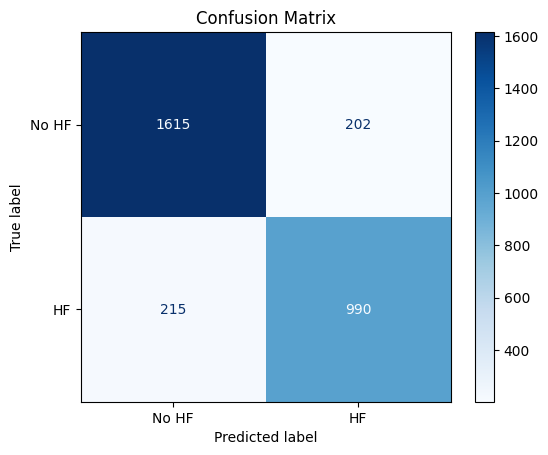

In [50]:
cm_256_weighted = confusion_matrix(y_test, y_pred_256_weighted)
disp_256_weighted = ConfusionMatrixDisplay(confusion_matrix=cm_256_weighted, display_labels=['No HF', 'HF'])
disp_256_weighted.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [51]:
print(classification_report(y_test, y_pred_256_weighted, target_names=["No HF", "HF"]))

              precision    recall  f1-score   support

       No HF       0.88      0.89      0.89      1817
          HF       0.83      0.82      0.83      1205

    accuracy                           0.86      3022
   macro avg       0.86      0.86      0.86      3022
weighted avg       0.86      0.86      0.86      3022



## Under-Sampling

### n - 32 Model

In [ ]:
model_32_us = load_model('models/ResidualCNN/Under_Sampled_ResidualCNN_FeatureExtractor_32.h5')

In [53]:
y_probs_32_us = model_32_us.predict(X_test, verbose=0)
y_pred_32_us = (y_probs_32_us >= 0.5).astype(int).flatten() 

In [54]:
# Accuracy
acc = accuracy_score(y_test, y_pred_32_us)

# Precision, Recall, F1
precision = precision_score(y_test, y_pred_32_us)
recall = recall_score(y_test, y_pred_32_us)
f1 = f1_score(y_test, y_pred_32_us)

# AUC
auc = roc_auc_score(y_test, y_probs_32_us)

# Print all
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC:       {auc:.4f}")

Accuracy:  0.8101
Precision: 0.7013
Recall:    0.9120
F1 Score:  0.7929
AUC:       0.9227


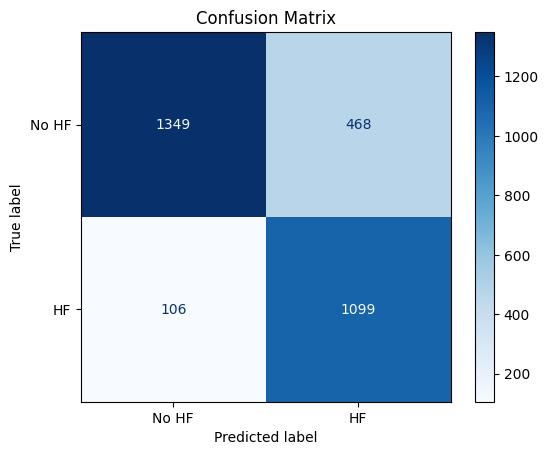

In [55]:
cm_32_us = confusion_matrix(y_test, y_pred_32_us)
disp_32_us = ConfusionMatrixDisplay(confusion_matrix=cm_32_us, display_labels=['No HF', 'HF'])
disp_32_us.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [56]:
print(classification_report(y_test, y_pred_32_us, target_names=["No HF", "HF"]))

              precision    recall  f1-score   support

       No HF       0.93      0.74      0.82      1817
          HF       0.70      0.91      0.79      1205

    accuracy                           0.81      3022
   macro avg       0.81      0.83      0.81      3022
weighted avg       0.84      0.81      0.81      3022



### n - 64 Model

In [ ]:
model_64_us = load_model('models/ResidualCNN/Under_Sampled_ResidualCNN_FeatureExtractor_64.h5')

In [58]:
y_probs_64_us = model_64_us.predict(X_test, verbose=0)
y_pred_64_us = (y_probs_64_us >= 0.5).astype(int).flatten() 

In [59]:
# Accuracy
acc = accuracy_score(y_test, y_pred_64_us)

# Precision, Recall, F1
precision = precision_score(y_test, y_pred_64_us)
recall = recall_score(y_test, y_pred_64_us)
f1 = f1_score(y_test, y_pred_64_us)

# AUC
auc = roc_auc_score(y_test, y_probs_64_us)

# Print all
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC:       {auc:.4f}")

Accuracy:  0.8564
Precision: 0.7883
Recall:    0.8747
F1 Score:  0.8293
AUC:       0.9335


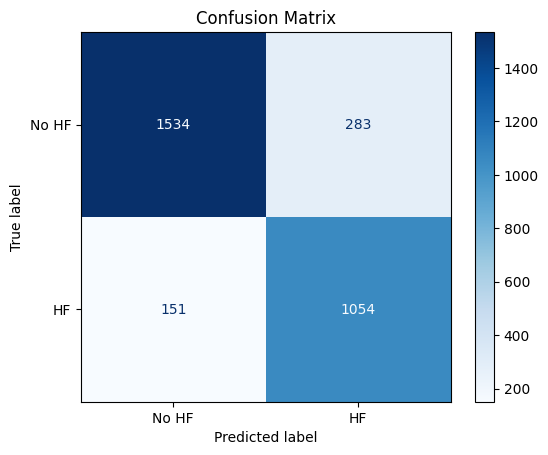

In [60]:
cm_64_us = confusion_matrix(y_test, y_pred_64_us)
disp_64_us = ConfusionMatrixDisplay(confusion_matrix=cm_64_us, display_labels=['No HF', 'HF'])
disp_64_us.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [61]:
print(classification_report(y_test, y_pred_64_us, target_names=["No HF", "HF"]))

              precision    recall  f1-score   support

       No HF       0.91      0.84      0.88      1817
          HF       0.79      0.87      0.83      1205

    accuracy                           0.86      3022
   macro avg       0.85      0.86      0.85      3022
weighted avg       0.86      0.86      0.86      3022



### n - 128 Model

In [ ]:
model_128_us = load_model('models/ResidualCNN/Under_Sampled_ResidualCNN_FeatureExtractor_128.h5')

In [63]:
y_probs_128_us = model_128_us.predict(X_test, verbose=0)
y_pred_128_us = (y_probs_128_us >= 0.5).astype(int).flatten() 

In [64]:
# Accuracy
acc = accuracy_score(y_test, y_pred_128_us)

# Precision, Recall, F1
precision = precision_score(y_test, y_pred_128_us)
recall = recall_score(y_test, y_pred_128_us)
f1 = f1_score(y_test, y_pred_128_us)

# AUC
auc = roc_auc_score(y_test, y_probs_128_us)

# Print all
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC:       {auc:.4f}")

Accuracy:  0.8680
Precision: 0.8261
Recall:    0.8473
F1 Score:  0.8365
AUC:       0.9390


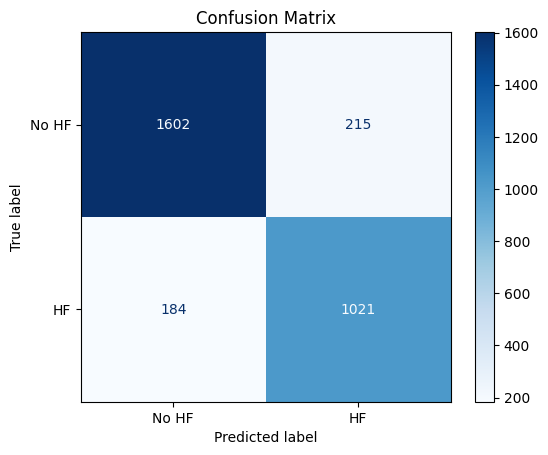

In [65]:
cm_128_us = confusion_matrix(y_test, y_pred_128_us)
disp_128_us = ConfusionMatrixDisplay(confusion_matrix=cm_128_us, display_labels=['No HF', 'HF'])
disp_128_us.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [66]:
print(classification_report(y_test, y_pred_128_us, target_names=["No HF", "HF"]))

              precision    recall  f1-score   support

       No HF       0.90      0.88      0.89      1817
          HF       0.83      0.85      0.84      1205

    accuracy                           0.87      3022
   macro avg       0.86      0.86      0.86      3022
weighted avg       0.87      0.87      0.87      3022



### n - 256 Model

In [ ]:
model_256_us = load_model('models/ResidualCNN/Under_Sampled_ResidualCNN_FeatureExtractor_256.h5')

In [68]:
y_probs_256_us = model_256_us.predict(X_test, verbose=0)
y_pred_256_us = (y_probs_256_us >= 0.5).astype(int).flatten() 

In [69]:
# Accuracy
acc = accuracy_score(y_test, y_pred_256_us)

# Precision, Recall, F1
precision = precision_score(y_test, y_pred_256_us)
recall = recall_score(y_test, y_pred_256_us)
f1 = f1_score(y_test, y_pred_256_us)

# AUC
auc = roc_auc_score(y_test, y_probs_256_us)

# Print all
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC:       {auc:.4f}")

Accuracy:  0.8769
Precision: 0.8619
Recall:    0.8232
F1 Score:  0.8421
AUC:       0.9441


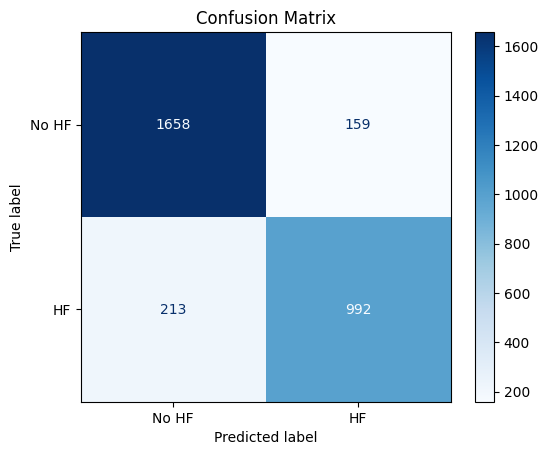

In [70]:
cm_256_us = confusion_matrix(y_test, y_pred_256_us)
disp_256_us = ConfusionMatrixDisplay(confusion_matrix=cm_256_us, display_labels=['No HF', 'HF'])
disp_256_us.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [71]:
print(classification_report(y_test, y_pred_256_us, target_names=["No HF", "HF"]))

              precision    recall  f1-score   support

       No HF       0.89      0.91      0.90      1817
          HF       0.86      0.82      0.84      1205

    accuracy                           0.88      3022
   macro avg       0.87      0.87      0.87      3022
weighted avg       0.88      0.88      0.88      3022



## Over Sampling

### n - 32 Model

In [ ]:
model_32_os = load_model('models/ResidualCNN/Over_Sampled_ResidualCNN_FeatureExtractor_32.h5')

In [73]:
y_probs_32_os = model_32_os.predict(X_test, verbose=0)
y_pred_32_os = (y_probs_32_os >= 0.5).astype(int).flatten() 

In [74]:
# Accuracy
acc = accuracy_score(y_test, y_pred_32_os)

# Precision, Recall, F1
precision = precision_score(y_test, y_pred_32_os)
recall = recall_score(y_test, y_pred_32_os)
f1 = f1_score(y_test, y_pred_32_os)

# AUC
auc = roc_auc_score(y_test, y_probs_32_os)

# Print all
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC:       {auc:.4f}")

Accuracy:  0.8845
Precision: 0.8609
Recall:    0.8473
F1 Score:  0.8540
AUC:       0.9491


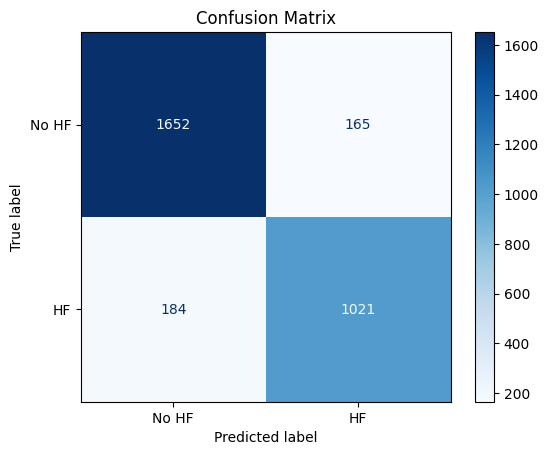

In [75]:
cm_32_os = confusion_matrix(y_test, y_pred_32_os)
disp_32_os = ConfusionMatrixDisplay(confusion_matrix=cm_32_os, display_labels=['No HF', 'HF'])
disp_32_os.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


In [76]:
print(classification_report(y_test, y_pred_32_os, target_names=["No HF", "HF"]))

              precision    recall  f1-score   support

       No HF       0.90      0.91      0.90      1817
          HF       0.86      0.85      0.85      1205

    accuracy                           0.88      3022
   macro avg       0.88      0.88      0.88      3022
weighted avg       0.88      0.88      0.88      3022



### n - 64 Model

In [ ]:
model_64_os = load_model('models/ResidualCNN/Over_Sampled_ResidualCNN_FeatureExtractor_64.h5')

In [78]:
y_probs_64_os = model_64_os.predict(X_test, verbose=0)
y_pred_64_os = (y_probs_64_os >= 0.5).astype(int).flatten()

In [79]:
# Accuracy
acc = accuracy_score(y_test, y_pred_64_os)

# Precision, Recall, F1
precision = precision_score(y_test, y_pred_64_os)
recall = recall_score(y_test, y_pred_64_os)
f1 = f1_score(y_test, y_pred_64_os)

# AUC
auc = roc_auc_score(y_test, y_probs_64_os)

# Print all
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC:       {auc:.4f}")

Accuracy:  0.8514
Precision: 0.7821
Recall:    0.8697
F1 Score:  0.8236
AUC:       0.9313


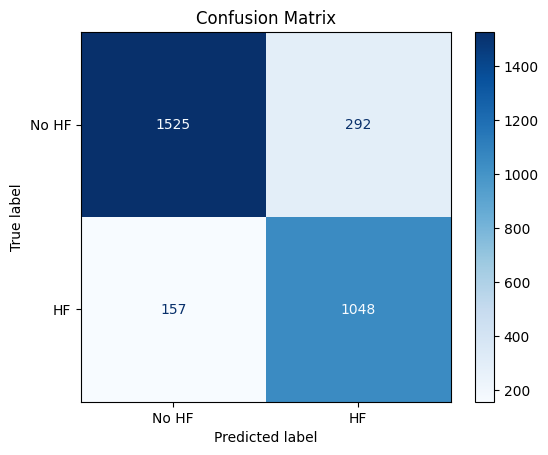

In [80]:
cm_64_os = confusion_matrix(y_test, y_pred_64_os)
disp_64_os = ConfusionMatrixDisplay(confusion_matrix=cm_64_os, display_labels=['No HF', 'HF'])
disp_64_os.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [81]:
print(classification_report(y_test, y_pred_64_os, target_names=["No HF", "HF"]))

              precision    recall  f1-score   support

       No HF       0.91      0.84      0.87      1817
          HF       0.78      0.87      0.82      1205

    accuracy                           0.85      3022
   macro avg       0.84      0.85      0.85      3022
weighted avg       0.86      0.85      0.85      3022



### n - 128 Model

In [ ]:
model_128_os = load_model('models/ResidualCNN/Over_Sampled_ResidualCNN_FeatureExtractor_128.h5')

In [83]:
y_probs_128_os = model_128_os.predict(X_test, verbose=0)
y_pred_128_os = (y_probs_128_os >= 0.5).astype(int).flatten() 

In [84]:
# Accuracy
acc = accuracy_score(y_test, y_pred_128_os)

# Precision, Recall, F1
precision = precision_score(y_test, y_pred_128_os)
recall = recall_score(y_test, y_pred_128_os)
f1 = f1_score(y_test, y_pred_128_os)

# AUC
auc = roc_auc_score(y_test, y_probs_128_os)

# Print all
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC:       {auc:.4f}")

Accuracy:  0.8713
Precision: 0.8417
Recall:    0.8340
F1 Score:  0.8378
AUC:       0.9379


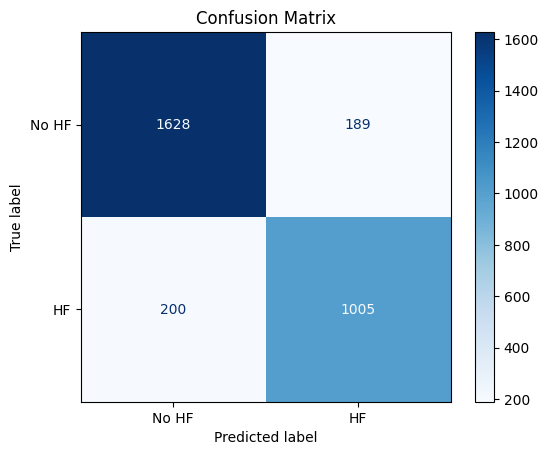

In [85]:
cm_128_os = confusion_matrix(y_test, y_pred_128_os)
disp_128_os = ConfusionMatrixDisplay(confusion_matrix=cm_128_os, display_labels=['No HF', 'HF'])
disp_128_os.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [86]:
print(classification_report(y_test, y_pred_128_os, target_names=["No HF", "HF"]))

              precision    recall  f1-score   support

       No HF       0.89      0.90      0.89      1817
          HF       0.84      0.83      0.84      1205

    accuracy                           0.87      3022
   macro avg       0.87      0.87      0.87      3022
weighted avg       0.87      0.87      0.87      3022



### n - 256 Model

In [ ]:
model_256_os = load_model('models/ResidualCNN/ResidualCNN_FeatureExtractor_256.h5')

In [88]:
y_probs_256_os = model_256_os.predict(X_test, verbose=0)
y_pred_256_os = (y_probs_256_os >= 0.5).astype(int).flatten() 

In [89]:
# Accuracy
acc = accuracy_score(y_test, y_pred_256_os)

# Precision, Recall, F1
precision = precision_score(y_test, y_pred_256_os)
recall = recall_score(y_test, y_pred_256_os)
f1 = f1_score(y_test, y_pred_256_os)

# AUC
auc = roc_auc_score(y_test, y_probs_256_os)

# Print all
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC:       {auc:.4f}")

Accuracy:  0.8673
Precision: 0.8328
Recall:    0.8349
F1 Score:  0.8338
AUC:       0.9365


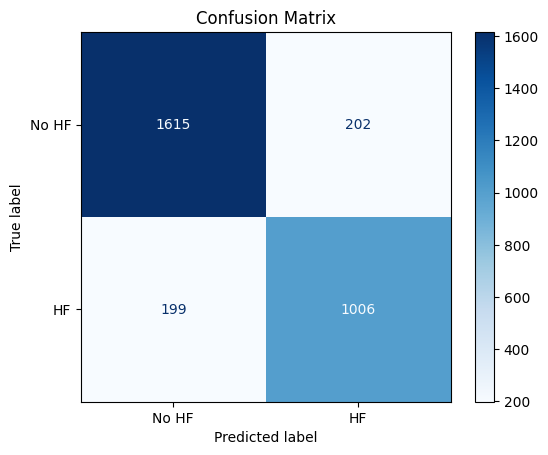

In [90]:
cm_256_os = confusion_matrix(y_test, y_pred_256_os)
disp_256_os = ConfusionMatrixDisplay(confusion_matrix=cm_256_os, display_labels=['No HF', 'HF'])
disp_256_os.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [91]:
print(classification_report(y_test, y_pred_256_os, target_names=["No HF", "HF"]))

              precision    recall  f1-score   support

       No HF       0.89      0.89      0.89      1817
          HF       0.83      0.83      0.83      1205

    accuracy                           0.87      3022
   macro avg       0.86      0.86      0.86      3022
weighted avg       0.87      0.87      0.87      3022

